# EDA

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from src.common.utils import get_root_directory
from src.visualisation.plotter import Plotter
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import calendar
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy
import gensim
from gensim.utils import simple_preprocess
from src.sentiment_analyser.bert_sentiment_analyser import BertSentimentAnalyser
from src.sentiment_analyser.vader_sentiment_analyser import VaderSentimentAnalyser

## Google News Headlines

In [50]:
root_dir = get_root_directory()
plotter = Plotter(root_dir)
processed_gn = pd.read_csv(f"{root_dir}\\data\\final\\sentiment_analysis.csv")

In [51]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156574 entries, 0 to 156573
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   156574 non-null  object 
 1   News Headline          156574 non-null  object 
 2   Publisher              156574 non-null  object 
 3   D_VADER_Score          156574 non-null  float64
 4   D_VADER_Sent           156574 non-null  int64  
 5   D_FINBERT_ConScore     156574 non-null  float64
 6   D_FINBERT_Sent         156574 non-null  int64  
 7   D_CRYPTOBERT_ConScore  156574 non-null  float64
 8   D_CRYPTOBERT_Sent      156574 non-null  int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 10.8+ MB


In [52]:
index = processed_gn.loc[processed_gn["Date"]=="2024-04-01"].index

In [53]:
processed_gn = processed_gn.loc[:max(index)]

In [54]:
processed_gn['Date'] = pd.to_datetime(processed_gn['Date'])

In [55]:
publishers = list(processed_gn['Publisher'].unique())

In [56]:
len(publishers)

7223

In [57]:
headlines = list(processed_gn['News Headline'].unique()) 

In [58]:
len(headlines)

134135

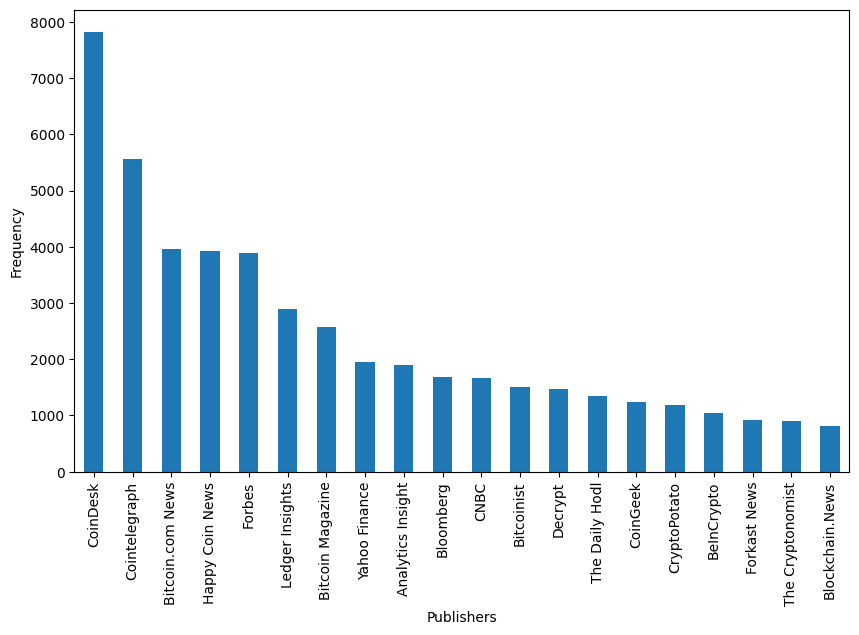

In [59]:
n = 20
top_n = processed_gn['Publisher'].value_counts().nlargest(n)
plotter = Plotter(root_dir)
plotter.plot_barchart(df=top_n, x="Publishers", y="Frequency")

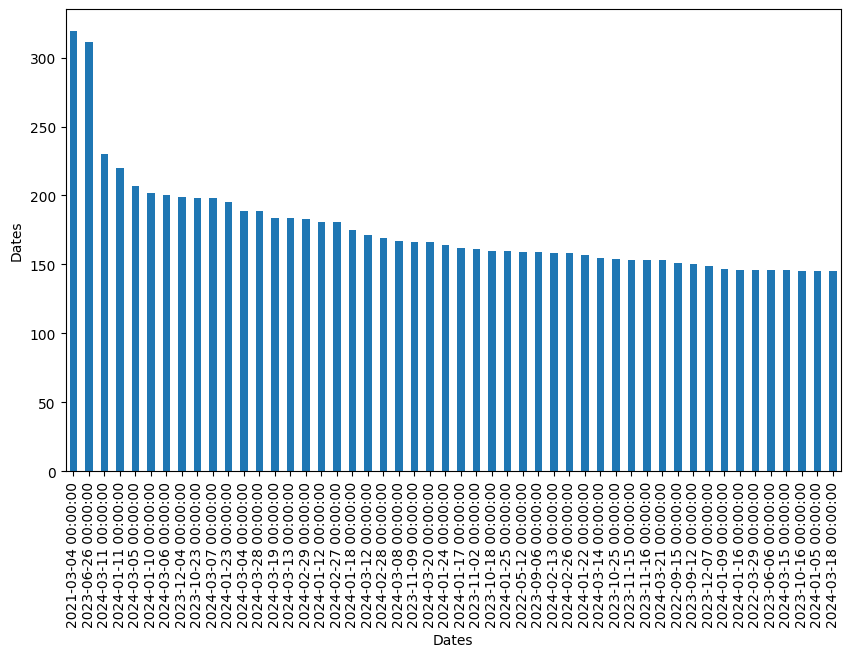

In [12]:
n = 50
top_n = processed_gn['Date'].value_counts().nlargest(n)
plotter.plot_barchart(df=top_n, x="Dates", y="Dates")

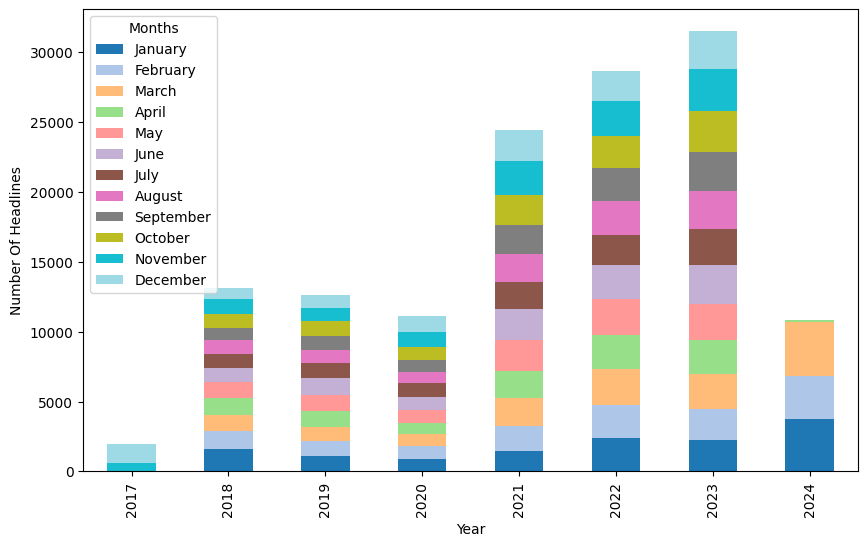

In [60]:
processed_gn['year'] = processed_gn['Date'].dt.year
processed_gn['month'] =processed_gn['Date'].dt.month
processed_gn['month_name'] = processed_gn['Date'].dt.month_name()
grouped = processed_gn.groupby(['year', 'month_name']).size().unstack(fill_value=0)
months_order = list(calendar.month_name)[1:] 
grouped = grouped.reindex(columns=months_order, fill_value=0)
grouped
plotter.plot_barchart(df=grouped, x="year", y="Number of Headlines", legend="Months", colormap="tab20",stacked=True)

In [56]:
plotter.save_graph()

In [61]:
processed_gn['length'] = processed_gn['News Headline'].apply(lambda x: len(x.split()))

In [62]:
extreme = list(processed_gn['News Headline'][processed_gn['length']==46])

In [63]:
processed_gn.describe()

,Date,D_VADER_Score,D_VADER_Sent,D_FINBERT_ConScore,D_FINBERT_Sent,D_CRYPTOBERT_ConScore,D_CRYPTOBERT_Sent,year,month,length
count,134135,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000
mean,2021-10-11 10:51:45.605546496,0.054286,0.134119,0.831877,0.013203,0.697649,0.168554,2021.299795,6.270295,13.148686
min,2017-11-09 00:00:00,-0.944200,-1.000000,0.336737,-1.000000,0.337411,-1.000000,2017.000000,1.000000,3.000000
25%,2020-07-16 00:00:00,0.000000,0.000000,0.774887,0.000000,0.570274,0.000000,2020.000000,3.000000,11.000000
50%,2022-02-16 00:00:00,0.000000,0.000000,0.882624,0.000000,0.671197,0.000000,2022.000000,6.000000,13.000000
75%,2023-04-22 00:00:00,0.258400,1.000000,0.925166,0.000000,0.821149,0.000000,2023.000000,9.000000,15.000000
max,2024-04-01 00:00:00,0.957800,1.000000,0.976155,1.000000,0.996783,1.000000,2024.000000,12.000000,46.000000
std,NaN,0.322609,0.699539,0.123792,0.476892,0.150100,0.429486,1.833964,3.567612,3.454540


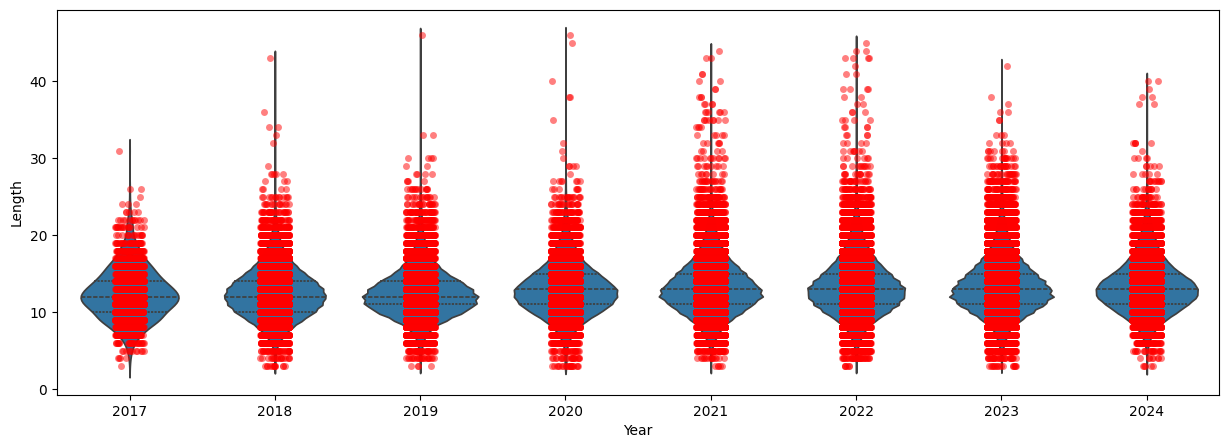

In [64]:
plotter.plot_violin_plot(df=processed_gn, x="year", y="length", stripplot = True, figsize=(15,5))

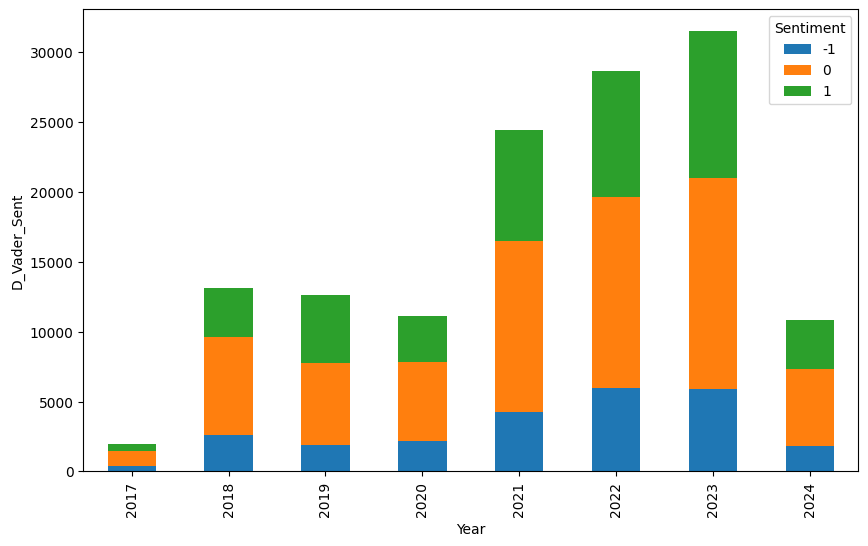

In [64]:
grouped = processed_gn.groupby(['year', 'D_VADER_Sent']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent", legend="Sentiment", stacked=True)
plotter.save_graph()

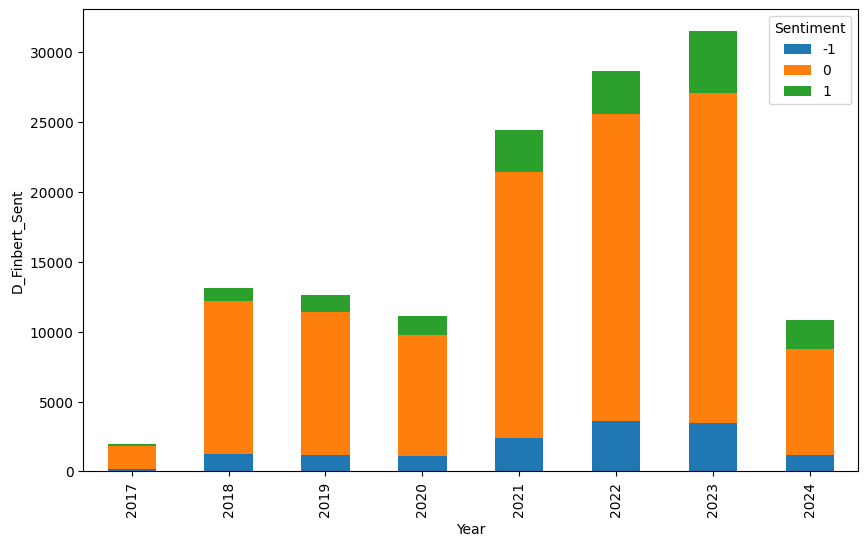

In [65]:
grouped = processed_gn.groupby(['year', 'D_FINBERT_Sent']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_FINBERT_Sent", legend="Sentiment", stacked=True)
plotter.save_graph()

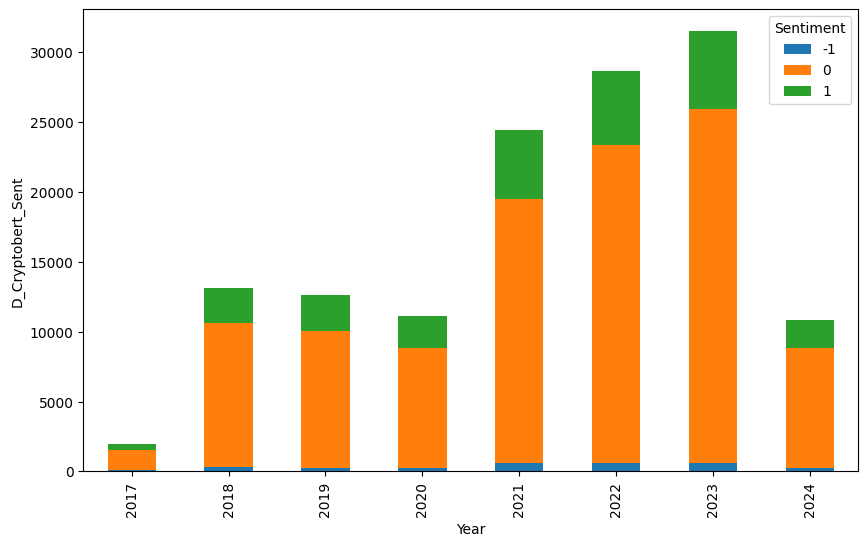

In [66]:
grouped = processed_gn.groupby(['year', 'D_CRYPTOBERT_Sent']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_CRYPTOBERT_Sent", legend="Sentiment", stacked=True)
plotter.save_graph()

In [65]:
VADER_AvgScr_In = processed_gn.pivot_table(values="D_VADER_Score", index=["Date"], aggfunc="mean")

In [66]:
VADER_AvgScr_In.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   D_VADER_Score  2336 non-null   float64
dtypes: float64(1)
memory usage: 36.5 KB


In [67]:
Features = VADER_AvgScr_In.rename(columns={"D_VADER_Score":"D_VADER_AvgScr_In"})

In [68]:
import swifter
def determine_score_sentiment(input_var:float)->int:
    if not isinstance(input_var, float):
        raise ValueError("Input must be a float")
    if input_var >= 0.05:
        return 1
    elif input_var <= -0.05:
        return -1
    else:
        return 0
    

In [69]:
Features["D_VADER_Sent_AvgIn"] = Features['D_VADER_AvgScr_In'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [70]:
dropped_neutrals = processed_gn.drop(processed_gn[processed_gn['D_VADER_Sent'] == 0].index)

In [71]:
VADER_AvgScr_Ex = dropped_neutrals.pivot_table(values="D_VADER_Score", index=["Date"], aggfunc="mean")

In [72]:
VADER_AvgScr_Ex.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   D_VADER_Score  2336 non-null   float64
dtypes: float64(1)
memory usage: 36.5 KB


In [73]:
Features["D_VADER_AvgScr_Ex"] = VADER_AvgScr_Ex["D_VADER_Score"]
Features["D_VADER_Sent_AvgEx"] = Features['D_VADER_AvgScr_Ex'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [74]:
Features

,D_VADER_AvgScr_In,D_VADER_Sent_AvgIn,D_VADER_AvgScr_Ex,D_VADER_Sent_AvgEx
Date,,,,
2017-11-09,0.082633,1,0.202827,1
2017-11-10,0.189088,1,0.267875,1
2017-11-11,0.065342,1,0.112014,1
2017-11-12,0.037093,0,0.088433,1
2017-11-13,0.036083,0,0.078931,1
...,...,...,...,...
2024-03-28,0.019836,0,0.037374,0
2024-03-29,0.058162,1,0.118291,1
2024-03-30,0.075112,1,0.187781,1


In [75]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134135 entries, 0 to 134134
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   134135 non-null  datetime64[ns]
 1   News Headline          134135 non-null  object        
 2   Publisher              134135 non-null  object        
 3   D_VADER_Score          134135 non-null  float64       
 4   D_VADER_Sent           134135 non-null  int64         
 5   D_FINBERT_ConScore     134135 non-null  float64       
 6   D_FINBERT_Sent         134135 non-null  int64         
 7   D_CRYPTOBERT_ConScore  134135 non-null  float64       
 8   D_CRYPTOBERT_Sent      134135 non-null  int64         
 9   year                   134135 non-null  int32         
 10  month                  134135 non-null  int32         
 11  month_name             134135 non-null  object        
 12  length                 134135 non-null  int6

In [76]:
processed_gn["D_FINBERT_AvgScr_In"] = processed_gn["D_FINBERT_ConScore"]*processed_gn["D_FINBERT_Sent"]
dropped_neutrals = processed_gn.drop(processed_gn[processed_gn['D_FINBERT_Sent'] == 0].index)
dropped_neutrals["D_FINBERT_AvgScr_Ex"] = dropped_neutrals["D_FINBERT_ConScore"]*dropped_neutrals["D_FINBERT_Sent"]

In [77]:
FINBERT_AvgScr_In = processed_gn.pivot_table(values="D_FINBERT_AvgScr_In", index=["Date"], aggfunc="mean")
FINBERT_AvgScr_Ex = dropped_neutrals.pivot_table(values="D_FINBERT_AvgScr_Ex", index=["Date"], aggfunc="mean")

In [78]:
FINBERT_AvgScr_Ex.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2316 entries, 2017-11-09 to 2024-04-01
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   D_FINBERT_AvgScr_Ex  2316 non-null   float64
dtypes: float64(1)
memory usage: 36.2 KB


In [79]:
Features["D_FINBERT_AvgScr_In"] = FINBERT_AvgScr_In["D_FINBERT_AvgScr_In"]
Features["D_FINBERT_Sent_AvgIn"] = Features['D_FINBERT_AvgScr_In'].swifter.apply(determine_score_sentiment)
Features["D_FINBERT_AvgScr_Ex"] = FINBERT_AvgScr_Ex["D_FINBERT_AvgScr_Ex"]
Features["D_FINBERT_Sent_AvgEx"] = Features['D_FINBERT_AvgScr_Ex'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [80]:
Features.index

DatetimeIndex(['2017-11-09', '2017-11-10', '2017-11-11', '2017-11-12',
               '2017-11-13', '2017-11-14', '2017-11-15', '2017-11-16',
               '2017-11-17', '2017-11-18',
               ...
               '2024-03-23', '2024-03-24', '2024-03-25', '2024-03-26',
               '2024-03-27', '2024-03-28', '2024-03-29', '2024-03-30',
               '2024-03-31', '2024-04-01'],
              dtype='datetime64[ns]', name='Date', length=2336, freq=None)

In [82]:
import numpy as np
Features.replace(np.nan, 0, inplace=True)

In [84]:
Features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   D_VADER_AvgScr_In     2336 non-null   float64
 1   D_VADER_Sent_AvgIn    2336 non-null   int64  
 2   D_VADER_AvgScr_Ex     2336 non-null   float64
 3   D_VADER_Sent_AvgEx    2336 non-null   int64  
 4   D_FINBERT_AvgScr_In   2336 non-null   float64
 5   D_FINBERT_Sent_AvgIn  2336 non-null   int64  
 6   D_FINBERT_AvgScr_Ex   2336 non-null   float64
 7   D_FINBERT_Sent_AvgEx  2336 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 228.8 KB


In [87]:
processed_gn["D_CRYPTOBERT_AvgScr_In"] = processed_gn["D_CRYPTOBERT_ConScore"]*processed_gn["D_CRYPTOBERT_Sent"]
dropped_neutrals = processed_gn.drop(processed_gn[processed_gn['D_CRYPTOBERT_Sent'] == 0].index)
dropped_neutrals["D_CRYPTOBERT_AvgScr_Ex"] = dropped_neutrals["D_CRYPTOBERT_ConScore"]*dropped_neutrals["D_CRYPTOBERT_Sent"]
CRYPTOBERT_AvgScr_In = processed_gn.pivot_table(values="D_CRYPTOBERT_AvgScr_In", index=["Date"], aggfunc="mean")
CRYPTOBERT_AvgScr_Ex = dropped_neutrals.pivot_table(values="D_CRYPTOBERT_AvgScr_Ex", index=["Date"], aggfunc="mean")
Features["D_CRYPTOBERT_AvgScr_In"] = CRYPTOBERT_AvgScr_In["D_CRYPTOBERT_AvgScr_In"]
Features["D_CRYPTOBERT_Sent_AvgIn"] = Features['D_CRYPTOBERT_AvgScr_In'].swifter.apply(determine_score_sentiment)
Features["D_CRYPTOBERT_AvgScr_Ex"] = CRYPTOBERT_AvgScr_Ex["D_CRYPTOBERT_AvgScr_Ex"]
Features["D_CRYPTOBERT_Sent_AvgEx"] = Features['D_CRYPTOBERT_AvgScr_Ex'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [88]:
Features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   D_VADER_AvgScr_In        2336 non-null   float64
 1   D_VADER_Sent_AvgIn       2336 non-null   int64  
 2   D_VADER_AvgScr_Ex        2336 non-null   float64
 3   D_VADER_Sent_AvgEx       2336 non-null   int64  
 4   D_FINBERT_AvgScr_In      2336 non-null   float64
 5   D_FINBERT_Sent_AvgIn     2336 non-null   int64  
 6   D_FINBERT_AvgScr_Ex      2336 non-null   float64
 7   D_FINBERT_Sent_AvgEx     2336 non-null   int64  
 8   D_CRYPTOBERT_AvgScr_In   2336 non-null   float64
 9   D_CRYPTOBERT_Sent_AvgIn  2336 non-null   int64  
 10  D_CRYPTOBERT_AvgScr_Ex   2331 non-null   float64
 11  D_CRYPTOBERT_Sent_AvgEx  2336 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 301.8 KB


In [89]:
Features.replace(np.nan, 0, inplace=True)

In [173]:
Features.describe()

,D_VADER_AvgScr_In,D_VADER_Sent_AvgIn,D_VADER_AvgScr_Ex,D_VADER_Sent_AvgEx,D_FINBERT_AvgScr_In,D_FINBERT_Sent_AvgIn,D_FINBERT_AvgScr_Ex,D_FINBERT_Sent_AvgEx,D_CRYPTOBERT_AvgScr_In,D_CRYPTOBERT_Sent_AvgIn,D_CRYPTOBERT_AvgScr_Ex,D_CRYPTOBERT_Sent_AvgEx,year
count,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000
mean,0.055925,0.485017,0.109182,0.593750,0.002320,0.030822,0.015684,0.050514,0.099024,0.883562,0.443815,0.963185,2020.558219
std,0.068034,0.601738,0.129647,0.663992,0.076212,0.696821,0.374210,0.943827,0.047273,0.328730,0.155405,0.242077,1.868949
min,-0.275347,-1.000000,-0.391283,-1.000000,-0.392865,-1.000000,-0.968635,-1.000000,-0.137297,-1.000000,-0.799251,-1.000000,2017.000000
25%,0.012935,0.000000,0.025894,0.000000,-0.045884,0.000000,-0.225103,-1.000000,0.071853,1.000000,0.373922,1.000000,2019.000000
50%,0.054986,1.000000,0.114122,1.000000,0.003931,0.000000,0.019197,0.000000,0.096156,1.000000,0.473349,1.000000,2021.000000
75%,0.093954,1.000000,0.189217,1.000000,0.051843,1.000000,0.255738,1.000000,0.124124,1.000000,0.558445,1.000000,2022.000000
max,0.344369,1.000000,0.587917,1.000000,0.331525,1.000000,0.935805,1.000000,0.328282,1.000000,0.756137,1.000000,2024.000000


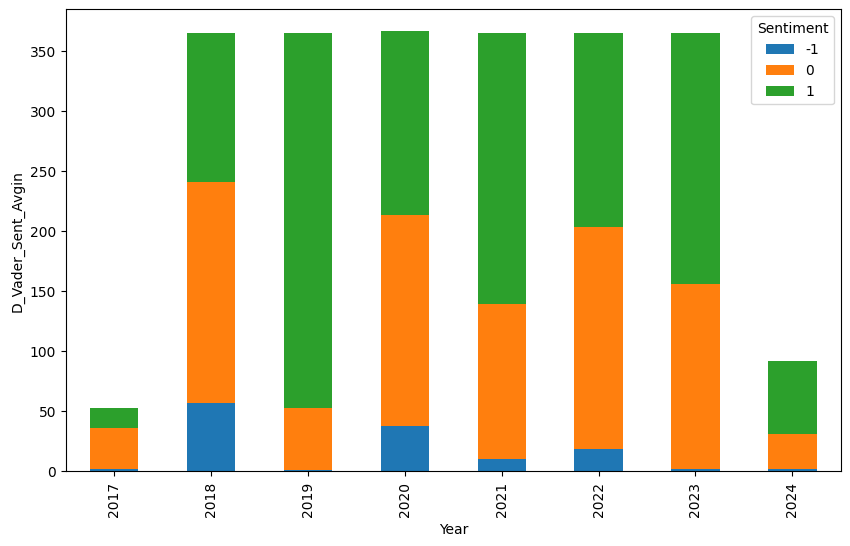

In [166]:
for_fea = Features
for_fea['year'] = for_fea.index.year
grouped = for_fea.groupby(['year', 'D_VADER_Sent_AvgIn']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent_AvgIn", legend="Sentiment", stacked=True)

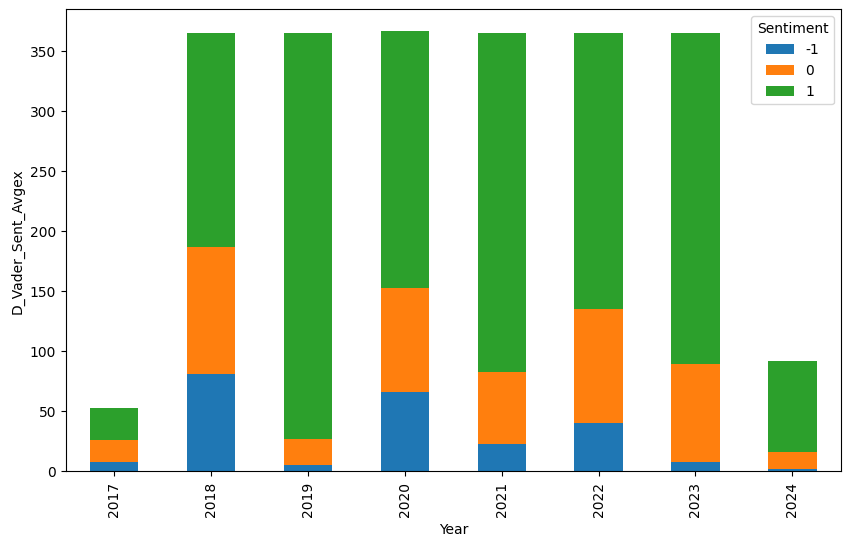

In [167]:
grouped = for_fea.groupby(['year', 'D_VADER_Sent_AvgEx']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent_AvgEx", legend="Sentiment", stacked=True)

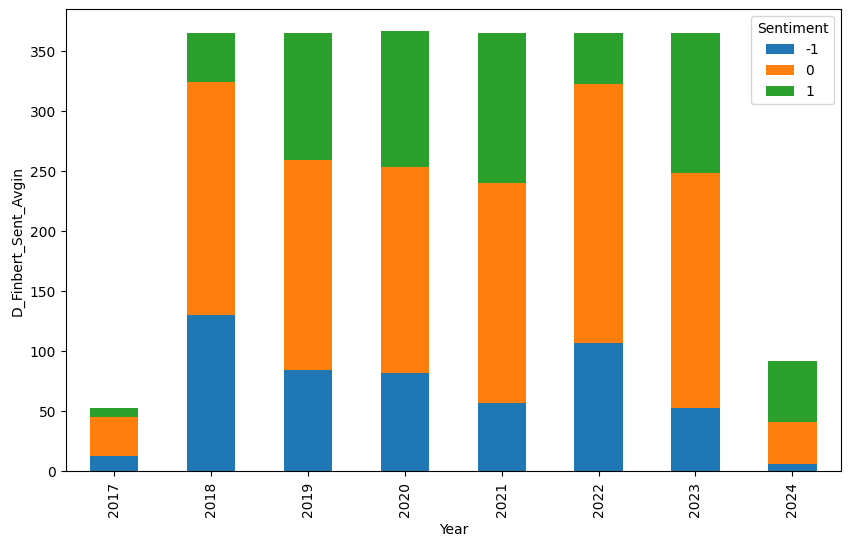

In [168]:
grouped = for_fea.groupby(['year', 'D_FINBERT_Sent_AvgIn']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_FINBERT_Sent_AvgIn", legend="Sentiment", stacked=True)

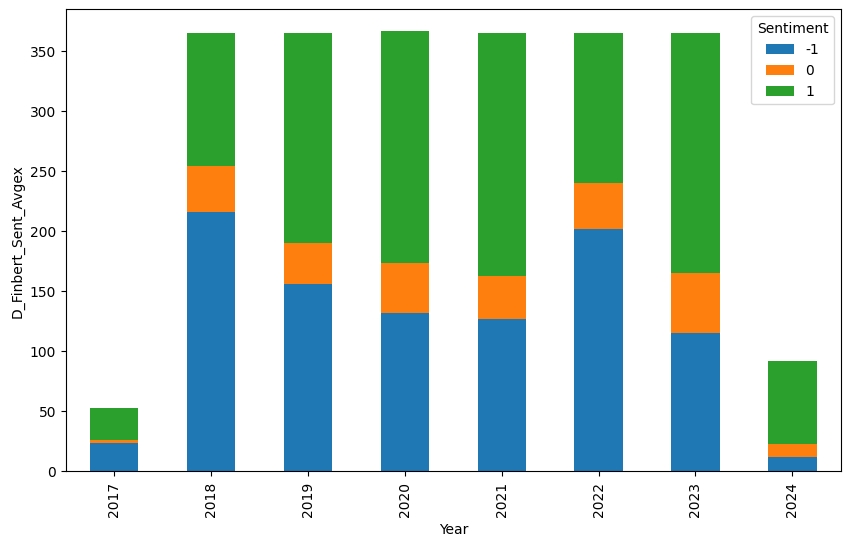

In [169]:
grouped = for_fea.groupby(['year', 'D_FINBERT_Sent_AvgEx']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_FINBERT_Sent_AvgEx", legend="Sentiment", stacked=True)

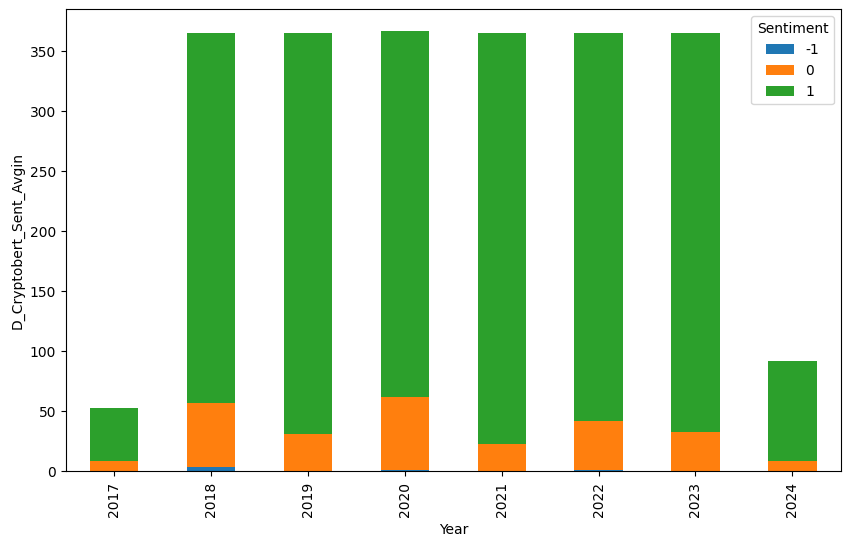

In [170]:
grouped = for_fea.groupby(['year', 'D_CRYPTOBERT_Sent_AvgIn']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_CRYPTOBERT_Sent_AvgIn", legend="Sentiment", stacked=True)

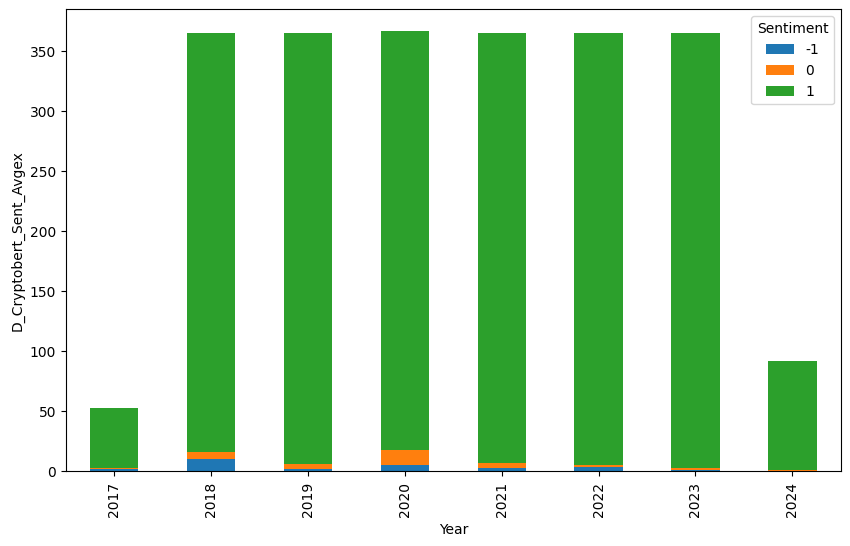

In [171]:
grouped = for_fea.groupby(['year', 'D_CRYPTOBERT_Sent_AvgEx']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_CRYPTOBERT_Sent_AvgEx", legend="Sentiment", stacked=True)

## Crypto Price Data

In [152]:
eth = pd.read_csv(f"{root_dir}\\data\\final\\ETH.csv")
eth["Date"]= pd.to_datetime(eth["Date"])
eth = eth.set_index("Date")
eth.columns = [f"ETH_{col}" for col in eth.columns]
btc = pd.read_csv(f"{root_dir}\\data\\final\\BTC.csv")
btc["Date"]= pd.to_datetime(btc["Date"])
btc = btc.set_index("Date")
btc.columns = [f"BTC_{col}" for col in btc.columns]
ltc = pd.read_csv(f"{root_dir}\\data\\final\\LTC.csv")
ltc["Date"]= pd.to_datetime(ltc["Date"])
ltc= ltc.set_index("Date")
ltc.columns = [f"BTC_{col}" for col in ltc.columns]

In [153]:
all_data = pd.concat([eth, btc, ltc, Features], axis=1)
drop_columns = [col for col in all_data.columns if ("YF" in col)]
corr = all_data.drop(columns=drop_columns)

In [154]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 63 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ETH_YF_Op                2336 non-null   float64
 1   ETH_YF_Hi                2336 non-null   float64
 2   ETH_YF_Lo                2336 non-null   float64
 3   ETH_YF_Cls               2336 non-null   float64
 4   ETH_YF_Vol               2336 non-null   int64  
 5   ETH_ES_AvgTransFee       2336 non-null   float64
 6   ETH_ES_AvgGasPrc         2336 non-null   int64  
 7   ETH_ES_BlkCnt            2336 non-null   int64  
 8   ETH_ES_BlkSz             2336 non-null   int64  
 9   ETH_ES_BlkTm             2336 non-null   float64
 10  ETH_ES_ActAdd            2336 non-null   int64  
 11  ETH_ES_DepCon            2336 non-null   int64  
 12  ETH_ES_GasLmt            2336 non-null   int64  
 13  ETH_ES_GasUsd            2336 non-null   int64  
 14  ETH_ES

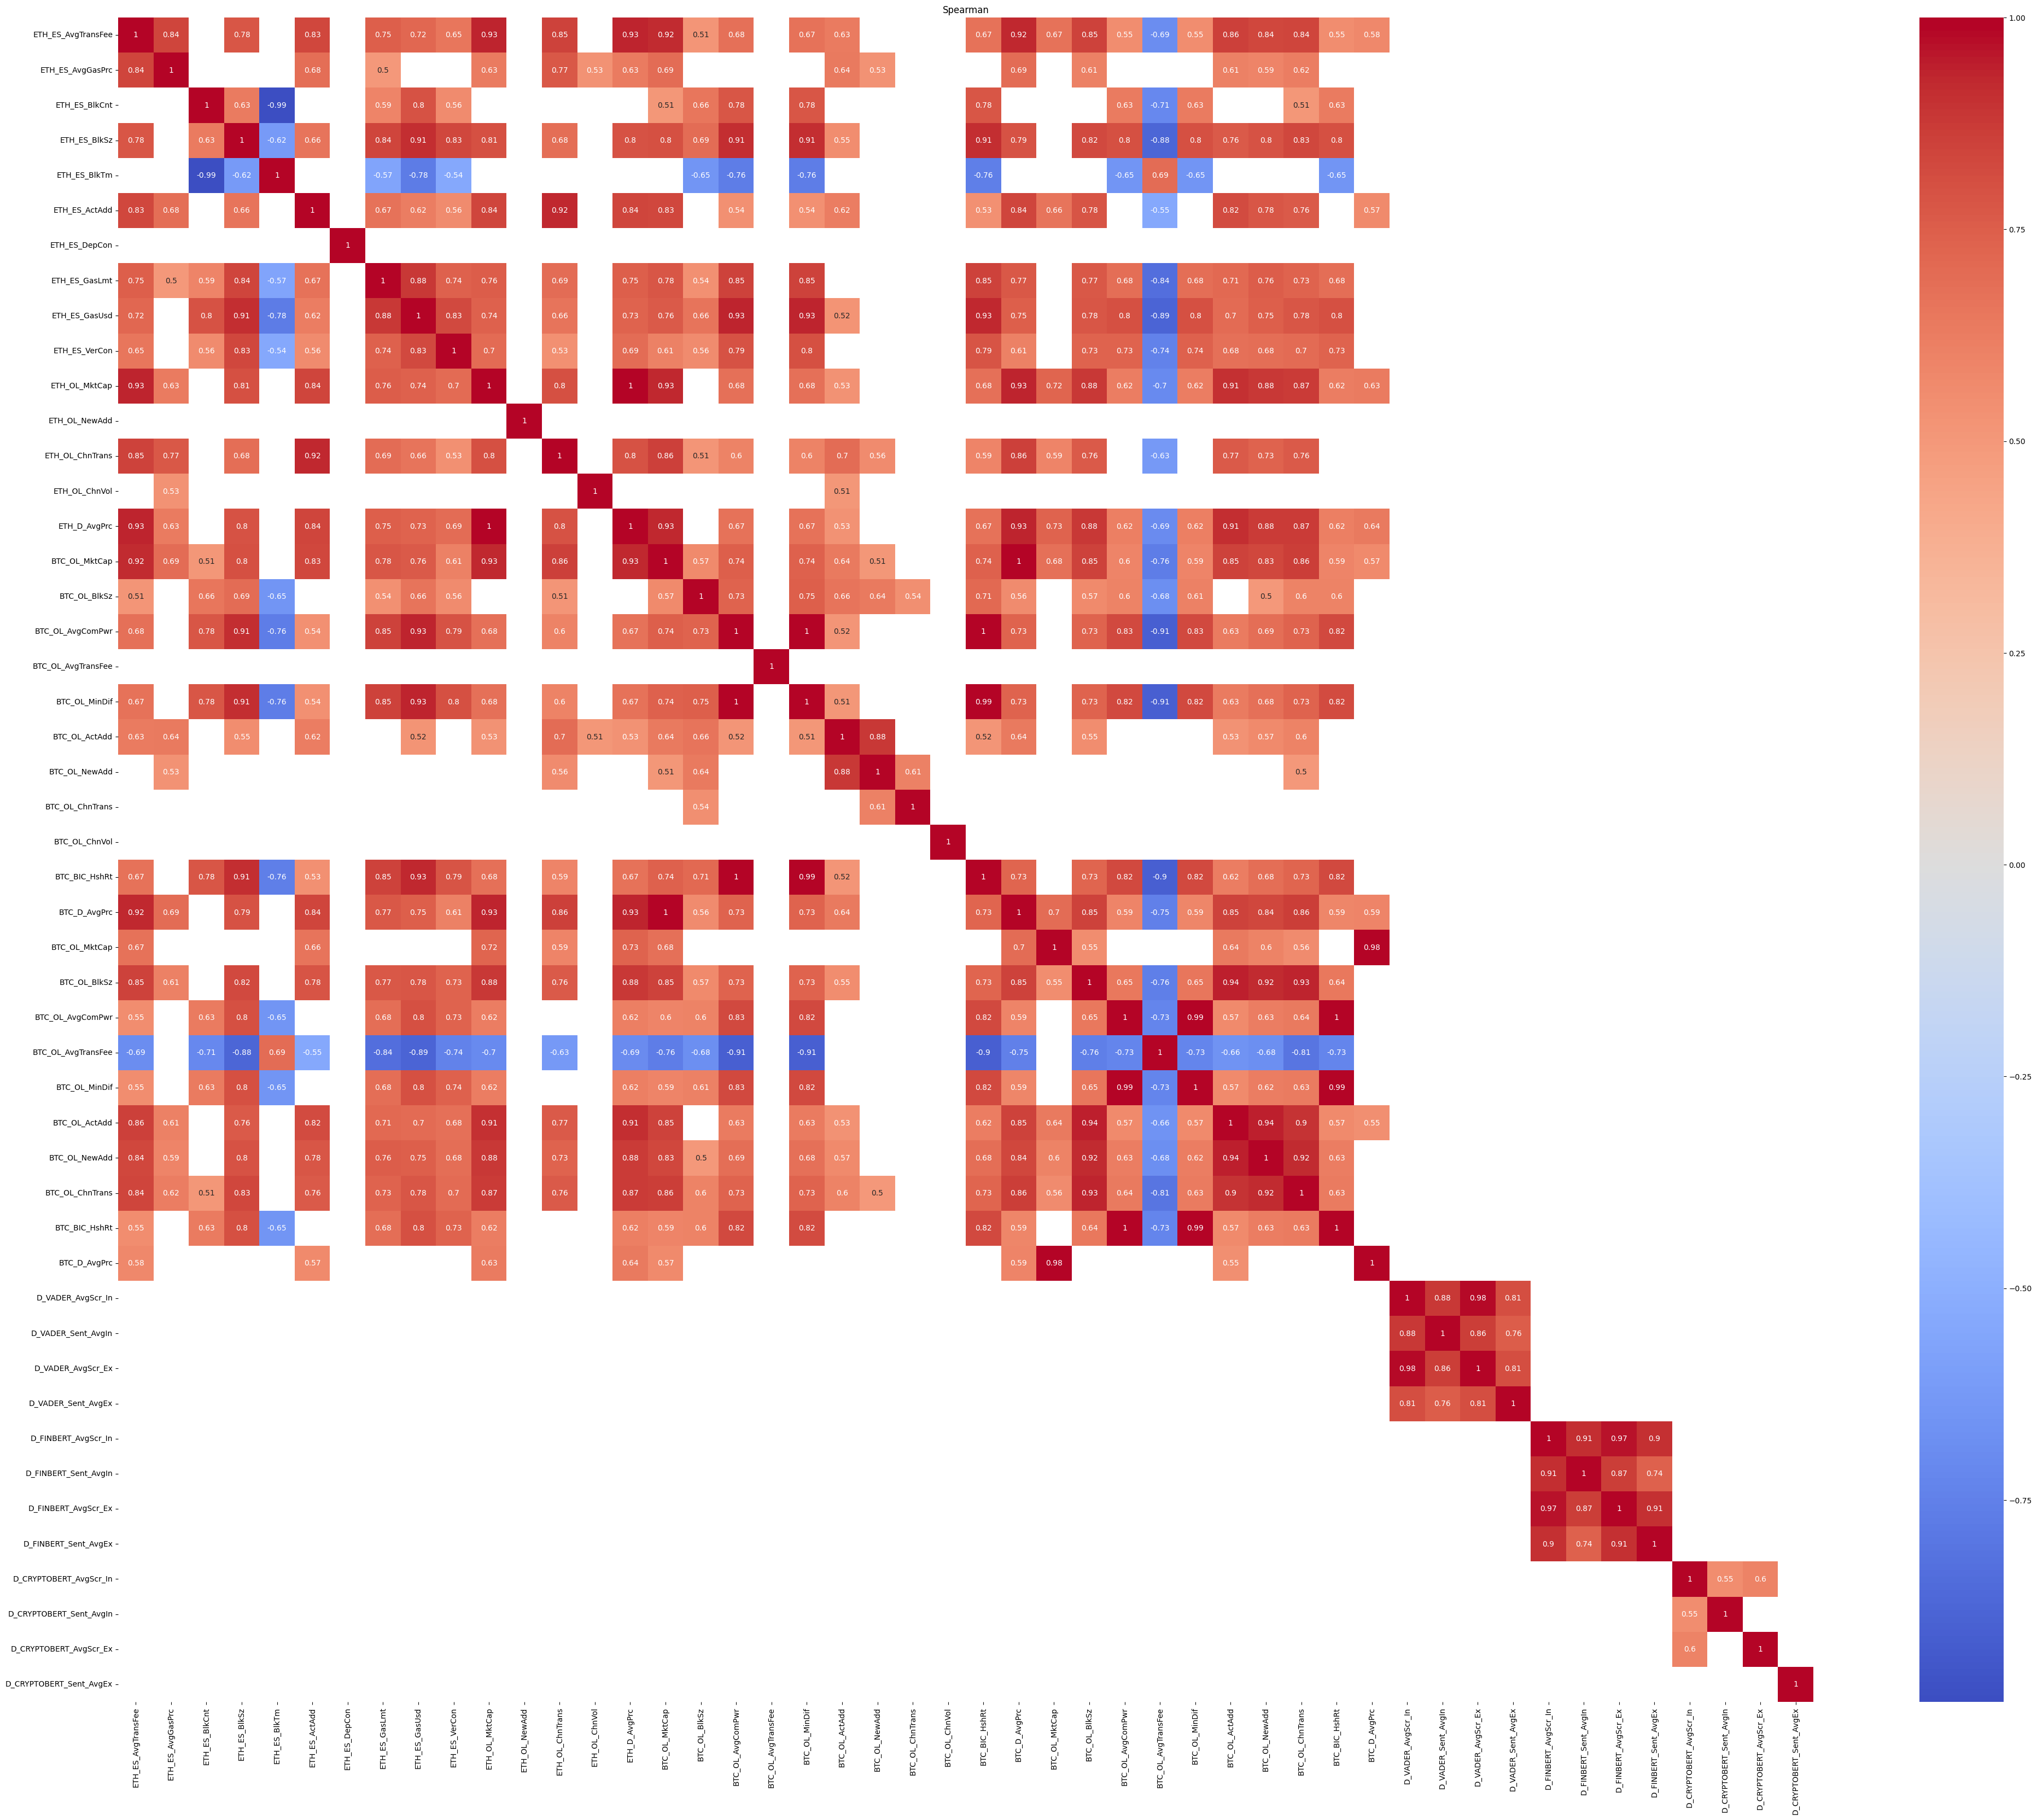

In [120]:
plotter.plot_correlation_matrix(corr, method="spearman", figsize=(50,40), title="Spearman", mask=True, threshold=0.5)

In [121]:
plotter.save_graph()

In [155]:
all_data['ETH_D_PrcDir'] = np.sign(all_data['ETH_D_AvgPrc'].diff())

In [156]:
all_data['ETH_D_PrcDir'].fillna(0, inplace=True)

In [157]:
drop_columns = [col for col in all_data.columns if ("YF" in col)]
corr = all_data.drop(columns=drop_columns)

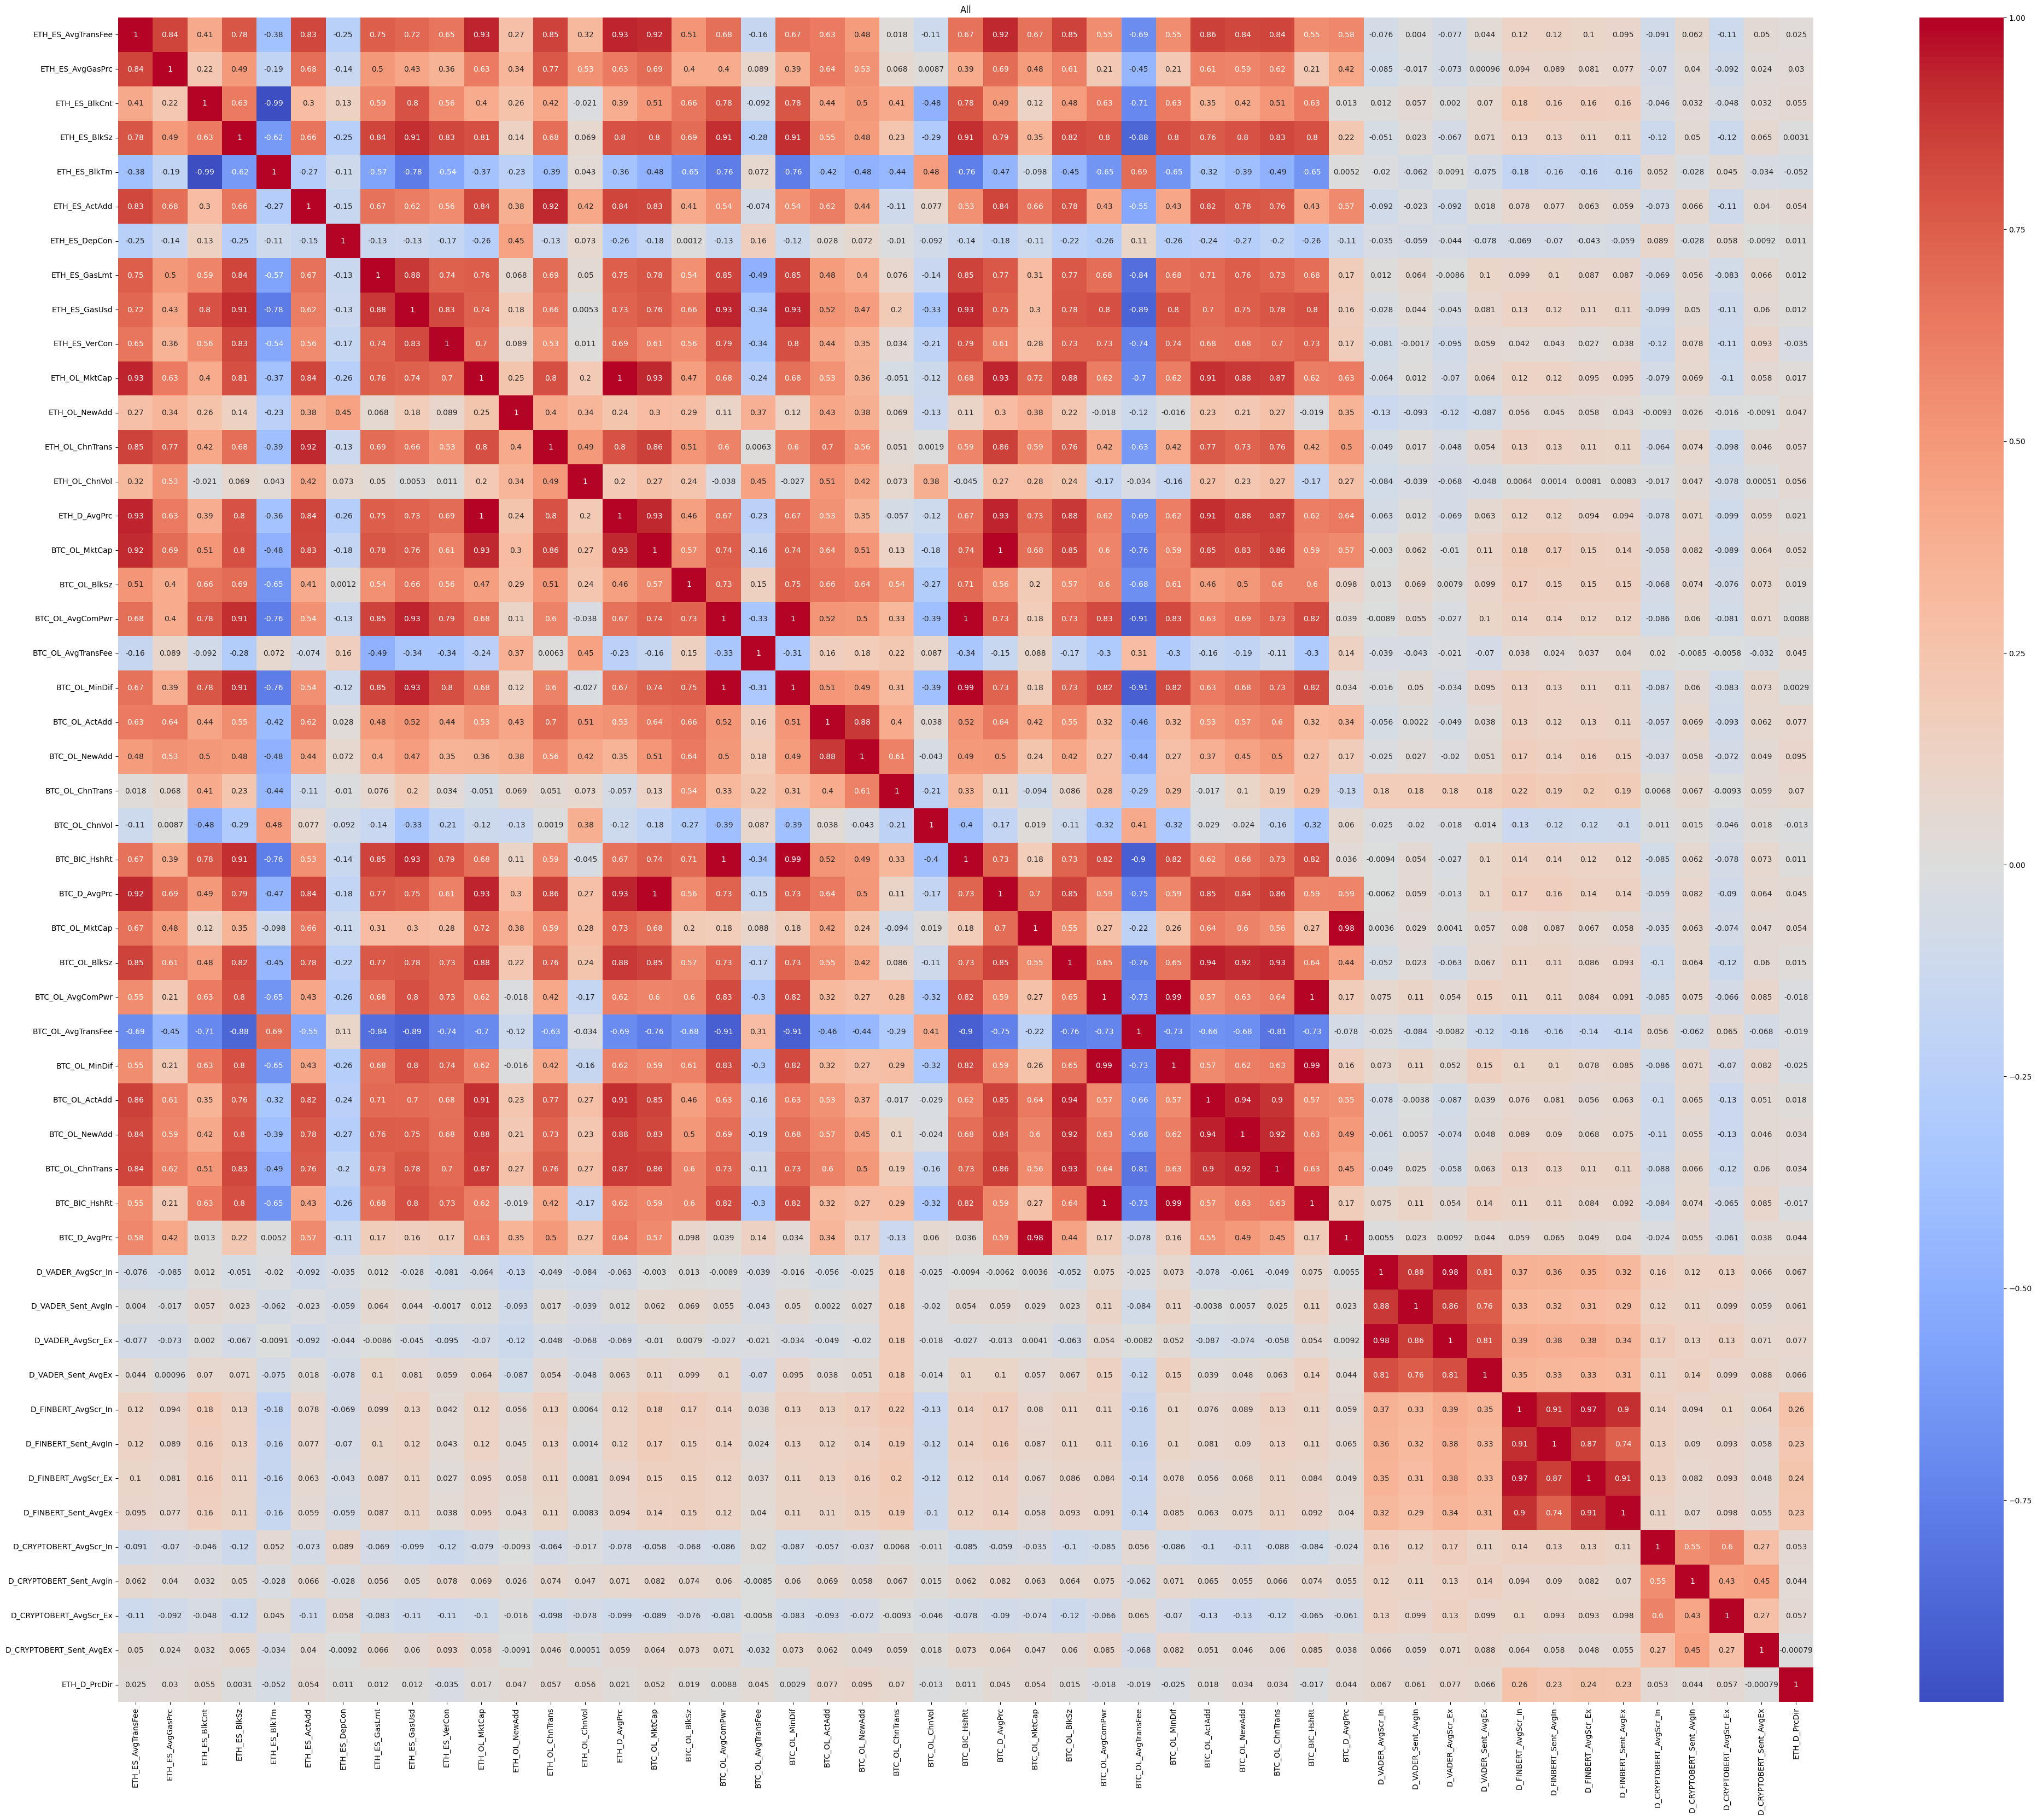

In [128]:
plotter.plot_correlation_matrix(corr, method="spearman", figsize=(50,40), title="All")

In [129]:
plotter.save_graph()

In [145]:
list(corr.columns)

['ETH_ES_AvgTransFee',
 'ETH_ES_AvgGasPrc',
 'ETH_ES_BlkCnt',
 'ETH_ES_BlkSz',
 'ETH_ES_BlkTm',
 'ETH_ES_ActAdd',
 'ETH_ES_DepCon',
 'ETH_ES_GasLmt',
 'ETH_ES_GasUsd',
 'ETH_ES_VerCon',
 'ETH_OL_MktCap',
 'ETH_OL_NewAdd',
 'ETH_OL_ChnTrans',
 'ETH_OL_ChnVol',
 'ETH_D_AvgPrc',
 'BTC_OL_MktCap',
 'BTC_OL_BlkSz',
 'BTC_OL_AvgComPwr',
 'BTC_OL_AvgTransFee',
 'BTC_OL_MinDif',
 'BTC_OL_ActAdd',
 'BTC_OL_NewAdd',
 'BTC_OL_ChnTrans',
 'BTC_OL_ChnVol',
 'BTC_BIC_HshRt',
 'BTC_D_AvgPrc',
 'BTC_OL_MktCap',
 'BTC_OL_BlkSz',
 'BTC_OL_AvgComPwr',
 'BTC_OL_AvgTransFee',
 'BTC_OL_MinDif',
 'BTC_OL_ActAdd',
 'BTC_OL_NewAdd',
 'BTC_OL_ChnTrans',
 'BTC_BIC_HshRt',
 'BTC_D_AvgPrc',
 'D_VADER_AvgScr_In',
 'D_VADER_Sent_AvgIn',
 'D_VADER_AvgScr_Ex',
 'D_VADER_Sent_AvgEx',
 'D_FINBERT_AvgScr_In',
 'D_FINBERT_Sent_AvgIn',
 'D_FINBERT_AvgScr_Ex',
 'D_FINBERT_Sent_AvgEx',
 'D_CRYPTOBERT_AvgScr_In',
 'D_CRYPTOBERT_Sent_AvgIn',
 'D_CRYPTOBERT_AvgScr_Ex',
 'D_CRYPTOBERT_Sent_AvgEx',
 'ETH_D_PrcDir']

In [159]:
lag_corr = corr[['ETH_D_AvgPrc','ETH_D_PrcDir']]

In [161]:
# next_day = lag_corr.index[-1] + pd.Timedelta(days=1)  # Get the next date
# empty_row = pd.DataFrame(index=[next_day], columns=lag_corr.columns)  # Create empty row
# lag_corr = pd.concat([lag_corr, empty_row])
for col in list(corr.columns):
    if col not in list(lag_corr.columns):
        lag_corr[col]=corr[col].shift(1)

C:\Users\rajdh\AppData\Local\Temp\ipykernel_20092\2249594131.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_corr[col]=corr[col].shift(1)
C:\Users\rajdh\AppData\Local\Temp\ipykernel_20092\2249594131.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_corr[col]=corr[col].shift(1)
C:\Users\rajdh\AppData\Local\Temp\ipykernel_20092\2249594131.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

ValueError: Cannot set a DataFrame with multiple columns to the single column BTC_OL_MktCap

In [162]:
lag_corr

,ETH_D_AvgPrc,ETH_D_PrcDir,ETH_ES_AvgTransFee,ETH_ES_AvgGasPrc,ETH_ES_BlkCnt,ETH_ES_BlkSz,ETH_ES_BlkTm,ETH_ES_ActAdd,ETH_ES_DepCon,ETH_ES_GasLmt,ETH_ES_GasUsd,ETH_ES_VerCon,ETH_OL_MktCap,ETH_OL_NewAdd,ETH_OL_ChnTrans,ETH_OL_ChnVol
Date,,,,,,,,,,,,,,,,
2017-11-09,316.509247,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-11-10,309.795990,-1.0,0.22,1.578557e+10,6195.0,13929.0,13.79,191221.0,51000.0,6718203.0,2.499807e+10,48.0,2.954960e+10,107924.0,484538.0,1.820082e+07
2017-11-11,307.727997,-1.0,0.19,1.503609e+10,6300.0,13413.0,13.52,189377.0,42629.0,6715532.0,2.370987e+10,67.0,2.923552e+10,100455.0,447845.0,1.367588e+07
2017-11-12,310.066002,1.0,0.19,1.539475e+10,6267.0,12665.0,13.58,160813.0,30604.0,6714315.0,2.267761e+10,31.0,2.893212e+10,90339.0,421015.0,1.320412e+07
2017-11-13,314.795250,1.0,0.21,1.801127e+10,6245.0,13233.0,13.83,184566.0,27014.0,6712808.0,2.292578e+10,56.0,2.939015e+10,95159.0,435550.0,1.820865e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-28,3534.136902,-1.0,11.41,3.981720e+10,6921.0,105555.0,12.39,519211.0,5492.0,29999806.0,1.050808e+11,249.0,4.212048e+11,154517.0,1302309.0,1.025451e+07
2024-03-29,3533.061218,-1.0,11.27,3.788605e+10,7028.0,108089.0,12.15,537315.0,5368.0,30000177.0,1.066808e+11,295.0,4.222416e+11,143722.0,1282280.0,8.347257e+06
2024-03-30,3518.939636,-1.0,8.62,2.908396e+10,7122.0,108567.0,12.09,572004.0,5703.0,30000145.0,1.081210e+11,256.0,4.158902e+11,151282.0,1298480.0,6.932854e+06


In [150]:
lag_corr

,ETH_D_AvgPrc,ETH_D_PrcDir,ETH_ES_AvgTransFee
Date,,,
2017-11-09,316.509247,0.0,NaN
2017-11-10,309.795990,-1.0,0.22
2017-11-11,307.727997,-1.0,0.19
2017-11-12,310.066002,1.0,0.19
2017-11-13,314.795250,1.0,0.21
...,...,...,...
2024-03-28,3534.136902,-1.0,11.41
2024-03-29,3533.061218,-1.0,11.27
2024-03-30,3518.939636,-1.0,8.62
